In [41]:
#import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
import nltk
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords

import re
import nltk
import emoji
import spacy
import string
import tensorflow as tf
import unicodedata
import datetime
from sklearn.utils import shuffle
# from joblib import dump, load
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import CSVLogger, TensorBoard, EarlyStopping
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from joblib import load

In [8]:
df = pd.read_excel('DateToTestSentiment_20210817.xls.xls')

In [10]:
df.dropna(subset=['RATING_VALUE'], inplace = True)

df['RATING_VALUE'] = df['RATING_VALUE'].str.replace(',', '.').astype(float).astype(int)

df['RATING_VALUE'].value_counts()

5    49246
4     8273
3     1921
1      953
2      445
Name: RATING_VALUE, dtype: int64

In [11]:
df['RATING_VALUE'].isna().sum()

0

In [42]:
def sentimento(x):
    """
    Função que transforma a coluna passada como argumento
    na variável target.
    """
    
    if x == 5:
        return 2
    elif x == 4:
        return 0
    else:
        return 1
    
    

def balance_classes(df):
    
    n4 = len(df[df['RATING_VALUE'] == 4])
    
    #
    df1 = df.loc[df['RATING_VALUE'] == 5, :]

    #
    df2 = df.loc[df['RATING_VALUE'] != 5, :]

    #
    df1 = df1.sample(n4)

    # contrói a tabela final
    df_final = df1.append(df2).reset_index().drop(columns=['index'])
    
    return df_final

def preprocess_data(data, columns,
                    label_column, 
                    null=True,
                    labels_ok=True, 
                    dict_labels=None,
                    labels_ready=True, 
                    labels_true=None):
    """ Função para tratamento de datasets para analise de sentimentos
    
    Args:
        data (pandas dataset) = Dataset 
        columns (list) = nome da coluna com texto para analise e da coluna com os labels
        null (Boolean) = define se vai limpar ou não os dados faltantes.
        label_columns (str)= nome da coluna com os label
        label_ok (Boolean) = define se a coluna de label está tratada ou não
        dict_label (dict) = define pelas chaves e valores as substituições vão ser feitas na coluna de labels.
        labels_ready (Boolean) = define se vamos usar os labels sem nenhuma alteração
        labels_true (dict) = dicionario com chaves sendo tuplas (com pelo menos dois elementos,
        mesmo que sejam elementos repetidos), com labels e valores sendo os respectivos 
        sentimentos (na ordem: positive, neutral e negative).
    """
    df = data[columns]
    
    if null:
        df = df.dropna().reset_index().drop(columns=['index'])
    
    if not labels_ok:
        for n, item in enumerate(df[label_column]):
            if type(item) == str:
                for key, value in dict_labels.items():
                    df[label_column][n] = re.sub(str(list(key)),value, df[label_column].iloc[n])
        df[label_column] = df[label_column].astype('float32')
                    
    if not labels_ready:
        def sentimento(x):
            if (x in [*labels_true.keys()][0]):
                return [*labels_true.values()][0]
            elif (x in [*labels_true.keys()][1]):
                return [*labels_true.values()][1]
            else:
                return [*labels_true.values()][2]
            
    df['sentimentos'] = df[label_column].apply(sentimento)    
    
    return df


def preprocess_text(text, 
                    remove_stop = True, 
                    stem_words = False, 
                    remove_mentions_hashtags = True
                   ):
    """
    eg:
    input: preprocess_text("@water #dream hi hello where are you going be there tomorrow happening happen happens",  
    stem_words = True) 
    output: ['tomorrow', 'happen', 'go', 'hello']
    """

    # Remove emojis
    emoji_pattern = re.compile("[" "\U0001F1E0-\U0001F6FF" "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r"", text)
    text = "".join([x for x in text if x not in emoji.UNICODE_EMOJI])
    
    # Corrige o bug que elimina parte das palavras com acentos
    text = ''.join(ch for ch in unicodedata.normalize('NFKD', text) 
    if not unicodedata.combining(ch))

    if remove_mentions_hashtags:
        text = re.sub(r"@(\w+)", " ", text)
        text = re.sub(r"#(\w+)", " ", text)

    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    regex = re.compile('[' + re.escape(string.punctuation) + '0-9\\r\\t\\n]')
    nopunct = regex.sub(" ", text.lower())
    words = (''.join(nopunct)).split()

    if(remove_stop):
        words = [w for w in words if w not in portuguese_stopwords]
        words = [w for w in words if len(w) > 2]  

    if(stem_words):
        stemmer = PorterStemmer()
        words = [stemmer.stem(w) for w in words]

    return list(words)


def tokenizacao(df):
    
    # cria a coluna com textos vetorizados
    rows, cols = df.shape

    df['token'] = [preprocess_text(df["COMMENT_TEXT"][row]) for row in range(rows)]
    
    return df


def treinar_vetorizacao(df):

    # coleciona as palavras usadas para o treinamento da função CountVectorizer
    lista_treino = []

    for item in df['token']:
        lista_treino1 = [n for n in item if n not in lista_treino]
        lista_treino.extend(lista_treino1)

    # treina o modelo de vetorização
    vectorize = CountVectorizer(lowercase=True, strip_accents = 'unicode')

    vectorize.fit(lista_treino)
    
    return vectorize, lista_treino


def vectorize2(lista):
    lista2 = [vectorize.vocabulary_[item] for item in lista]
    
    return lista2


def separa_df_test_train(df, size):

    #
    df = shuffle(df, random_state=42)

    # separando as variaveis
    X = df['vectors'].values

    #
    y = df['sentimentos'].values

    # usa a função pad_sequences do keras para deixar todos os textos do mesmo tamanho
    X = tf.keras.preprocessing.sequence.pad_sequences(X, maxlen=20)

    # separa os dados em treino e teste e fazendo o one-hot-encoding na variável y
    Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = size, random_state=42)

    #
    ytrain = tf.keras.utils.to_categorical(ytrain)

    #
    ytest = tf.keras.utils.to_categorical(ytest)

    return X, y, Xtrain, Xtest, ytrain, ytest


def redes_neurais_modelo():

    #
    model = tf.keras.Sequential()

    #
    model.add(tf.keras.layers.Embedding(input_dim = len(lista_treino) + 1, 
                                        output_dim = 128, 
                                        input_shape = (Xtrain.shape[1],), 
                                        activity_regularizer = regularizers.l2(1e-5)
                                       )
             )

    #
    model.add(tf.keras.layers.Dropout(0.25))

    #
    model.add(tf.keras.layers.LSTM(units = 512, activation='relu'))

    #
    model.add(tf.keras.layers.Dense(units = 256, activation='relu'))

    #
    model.add(tf.keras.layers.Dropout(0.25))

    #
    model.add(tf.keras.layers.Dense(units = 128, activation='relu'))

    #
    model.add(tf.keras.layers.Dropout(0.25))

    #
    model.add(tf.keras.layers.Dense(units = 64, activation='relu'))

    #
    model.add(tf.keras.layers.Dropout(0.25))

    #
    model.add(tf.keras.layers.Dense(units = 3, 
                                    activation='softmax', 
                                    activity_regularizer = regularizers.l2(1e-5)
                                   )
             )

    #
    model.compile(optimizer = 'Adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy']
                 )

    #
    model.summary()

    return model


def cria_stopper_rede(epo):

    # criando um stopper para a rede
    stopper = EarlyStopping(monitor="val_accuracy",
                             patience=5, 
                            verbose=2, 
                            mode='max'
                           )

    callbacks = [stopper]

    #
    history = model.fit(x = Xtrain, 
                        y = ytrain, 
                        batch_size = 128,
                        validation_data = (Xtest, ytest),
                        epochs = epo,
                        callbacks = callbacks
                        )
    
    return callbacks, history


def feelings_prediction(model):
    
    # organiza os labels pelo valor da rating dado pelo cliente
    dict_feeling = {2: 'Positive', 1: 'Negative', 0: 'Neutral'}

    text = input("Digite seu texto aqui\n\n")
    
    text1 = preprocess_text(text)
    
    text1 = [vectorize2(text1)]
    
    text1 = tf.keras.preprocessing.sequence.pad_sequences(text1, maxlen=20)
    
    pred = model.predict(text1)
    
    predd = dict_feeling[np.argmax(pred)]
    
    print('\nSentimento analisado:', predd)
    
    
def feelings_prediction_v02(model,df):
    
    # organiza os labels pelo valor da rating dado pelo cliente
    dict_feeling = {2: 'Positive', 1: 'Negative', 0: 'Neutral'}
       
    text = df['vectors'].values
    
    text = tf.keras.preprocessing.sequence.pad_sequences(text, maxlen=20)
    
    lista_pred = model.predict(text)
    
    df['pred_sentiment'] = [dict_feeling[np.argmax(item)] for item in lista_pred]
    
    return df

Word Count Median: 6.0
count    60838.000000
mean        10.653375
std         16.144284
min          1.000000
25%          2.000000
50%          6.000000
75%         13.000000
max        511.000000
Name: word_count, dtype: float64


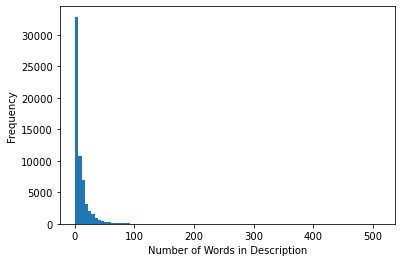

In [13]:
#add a column for the word count
df['word_count'] = df['COMMENT_TEXT'].apply(lambda x: len(str(x).split(" ")))

print("Word Count Median: " + str(df['word_count'].median()))
print(df['word_count'].describe())

x = df['word_count']

n_bins = 95
plt.hist(x, bins=n_bins)
plt.xlabel('Number of Words in Description')
plt.ylabel('Frequency')
plt.show()

5.0
count    60838.000000
mean         4.716263
std          0.705869
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: RATING_VALUE, dtype: float64


Text(0.5, 1.0, 'Points Counts')

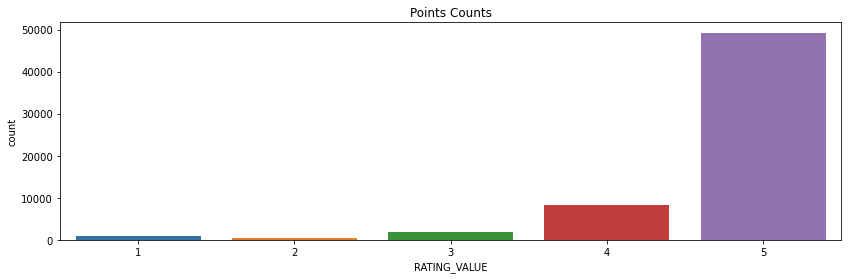

In [15]:
#word counts less than 1500
wc = df.loc[df['word_count'] < 1500]

print(wc.RATING_VALUE.median())
print(wc.RATING_VALUE.describe())

#plot the counts
plt.figure(figsize=(14,4))
sns.countplot(x = 'RATING_VALUE', data = wc).set_title("Points Counts")

In [44]:
portuguese_stopwords = nltk.corpus.stopwords.words('portuguese')

#
df2 = preprocess_data(df, 
                     columns=['KEY','COMMENT_ID','COMMENT_TEXT', 'RATING_VALUE'],
                     label_column='RATING_VALUE', 
                     null = True,
                     labels_ok = False,
                     dict_labels = {(' '): '', (','): '.'},
                     labels_ready = False, 
                     labels_true = {(5,5): 2, (4,4):0,(1,2,3):1}
                  )

# contruindo a coluna nova com os sentimentos
df2['sentimentos'] = df2['RATING_VALUE'].apply(sentimento)

#
df2 = tokenizacao(df2)

#
vectorize, lista_treino = treinar_vetorizacao(df2)


# criando a coluna com o texto vetorizado
df2['vectors'] = df2['token'].apply(vectorize2)

In [48]:
clean_desc = []

def create_clean_desc(df):
    
    for w in range(0,len(df.COMMENT_TEXT)):
        desc = df['COMMENT_TEXT'][w].lower()

        #remove punctuation
        # desc = re.sub('[^a-zA-Z]', ' ', desc)

        #remove tags
        desc = re.sub("&lt;/?.*?&gt;"," &lt;&gt; ",desc)

        #remove special characters and digits
        desc = re.sub("(\\d|\\W)+"," ",desc)

        split_text = desc.split()

        #Lemmatisation
        lem = WordNetLemmatizer()
        split_text = [lem.lemmatize(word) for word in split_text if not word in portuguese_stopwords and len(word) >2] 
        split_text = " ".join(split_text)
        clean_desc.append(split_text)
        
    return clean_desc

In [49]:
clean_desc = create_clean_desc(df2)

In [50]:
df2.head(2)

,KEY,COMMENT_ID,COMMENT_TEXT,RATING_VALUE,sentimentos,token,vectors
0,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,9018105,Ótimo,5.0,2,[otimo],[9627]
1,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,9011802,Ótimo,5.0,2,[otimo],[9627]


In [52]:
#TF-IDF vectorizer
tfv = TfidfVectorizer(stop_words = portuguese_stopwords, ngram_range = (1,1))

#transform
vec_text = tfv.fit_transform(clean_desc)

#returns a list of words.
words = tfv.get_feature_names()

In [54]:
tfv

TfidfVectorizer(stop_words=['de', 'a', 'o', 'que', 'e', 'é', 'do', 'da', 'em',
                            'um', 'para', 'com', 'não', 'uma', 'os', 'no', 'se',
                            'na', 'por', 'mais', 'as', 'dos', 'como', 'mas',
                            'ao', 'ele', 'das', 'à', 'seu', 'sua', ...])

In [55]:
#setup kmeans clustering
kmeans = KMeans(n_clusters = 10, n_init = 17, n_jobs = -1, tol = 0.01, max_iter = 200)

#fit the data 
kmeans.fit(vec_text)

#this loop transforms the numbers back into words
common_words = kmeans.cluster_centers_.argsort()[:,-1:-11:-1]
for num, centroid in enumerate(common_words):
    print(str(num) + ' : ' + ', '.join(words[word] for word in centroid))

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:792: FutureWarning: 'n_jobs' was deprecated in version 0.23 and will be removed in 1.0 (renaming of 0.25).
  warnings.warn("'n_jobs' was deprecated in version 0.23 and will be"


0 : produto, bom, celular, expectativas, bateria, ótimo, aparelho, excelente, qualidade, câmera
1 : top, gostei, chegou, amei, ante, prazo, produto, bom, entrega, celular
2 : custo, benefício, ótimo, bom, excelente, beneficio, produto, melhor, celular, aparelho
3 : maravilhoso, produto, amei, celular, simplesmente, lindo, bom, expectativas, amando, excelente
4 : otimo, produto, aparelho, celular, recomendo, bom, atendeu, beneficio, expectativas, custo
5 : recomendo, super, produto, bom, ótimo, excelente, celular, todos, aparelho, entrega
6 : ótimo, produto, aparelho, celular, bom, amei, lindo, tudo, preço, qualidade
7 : excelente, produto, aparelho, qualidade, celular, bom, ótimo, amei, compra, câmera
8 : perfeito, produto, tudo, amei, celular, bom, simplesmente, ótimo, estado, maravilhoso
9 : bom, produto, aparelho, celular, iphone, desempenho, sempre, preço, tecnologia, gostei
